# EDA of the DMEPOS - By Referral Provider & Supplier

In [1]:
# Loading Libraries
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd
import re
import csv

In [2]:
#Loading derived supplier dataset
df_sup = pd.read_csv("/dsa/groups/casestudycf25/team02/silver/dmepos_suplr_Bene_only.csv")
df_sup.head()

,Year,Suplr_NPI,Bene_Avg_Age,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,...,Bene_CC_PH_Diabetes_V2_Pct,Bene_CC_PH_HF_NonIHD_V2_Pct,Bene_CC_PH_Hyperlipidemia_V2_Pct,Bene_CC_PH_Hypertension_V2_Pct,Bene_CC_PH_IschemicHeart_V2_Pct,Bene_CC_PH_Osteoporosis_V2_Pct,Bene_CC_PH_Parkinson_V2_Pct,Bene_CC_PH_Arthritis_V2_Pct,Bene_CC_PH_Stroke_TIA_V2_Pct,Bene_Avg_Risk_Scre
0,2021,1003000399,72.919149,163.0,69.0,211.0,NaN,NaN,0.0,0.0,...,0.271552,0.120690,0.741379,0.650862,0.215517,0.189655,NaN,0.676724,0.094828,0.982410
1,2021,1003002254,71.058824,32.0,23.0,55.0,0.0,0.0,0.0,0.0,...,0.854545,0.236364,0.818182,0.836364,0.363636,NaN,NaN,0.272727,NaN,1.500596
2,2021,1003004904,74.692308,NaN,NaN,19.0,NaN,0.0,NaN,0.0,...,1.190476,NaN,1.095238,1.190476,0.809524,NaN,NaN,0.571429,NaN,2.327878
3,2021,1003004938,67.707692,42.0,24.0,62.0,NaN,0.0,0.0,0.0,...,0.757576,0.242424,0.757576,0.787879,0.318182,NaN,NaN,0.363636,NaN,1.693562
4,2021,1003007386,71.547619,22.0,16.0,37.0,NaN,0.0,0.0,0.0,...,1.000000,NaN,0.947368,0.973684,NaN,NaN,0.0,0.342105,NaN,1.188676


In [3]:
# Loading the LEIE exclusion list
df_exc = pd.read_csv("/dsa/groups/casestudycf25/team02/silver/leie_with_valid_npi_clean.csv",
                dtype={"Suplr_Prvdr_RUCA": "float64"}, na_values=["NA"])
df_exc.head()

,general,specialty,npi,excltype,excldate,num_exclusions_alltime,num_exclusion_types_alltime,list_exclusion_types_alltime,num_addresses_alltime,new_id,fraud_flag,excl_1128a1,excl_1128a2,excl_1128a3,excl_1128b5,excl_1128b6,excl_1128b7,excl_brch cia
0,IND- LIC HC SERV PRO,DENTIST,1.861529e+09,1128a3,2024-03-20,1.0,1.0,['1128a3'],1.0,AAMIR-WAHAB-nan-1979-11-16,1,0,0,1,0,0,0,0
1,IND- LIC HC SERV PRO,CHIROPRACTIC,1.366545e+09,1128b7,2021-08-16,1.0,1.0,['1128b7'],1.0,AARON-OXENRIDER-nan-1976-06-07,1,0,0,0,0,0,1,0
2,BUS OWNER/EXEC,LAB - CLINICAL,1.306284e+09,1128a1,2025-11-20,1.0,1.0,['1128a1'],1.0,AARON-ROSSI-nan-1983-02-20,1,1,0,0,0,0,0,0
3,IND- LIC HC SERV PRO,HEALTH CARE AIDE,1.376215e+09,1128a1,2025-01-20,1.0,1.0,['1128a1'],1.0,AARON-WALTON-nan-1971-11-19,1,1,0,0,0,0,0,0
4,BUS OWNER/EXEC,COUNSELING CENTER,1.326353e+09,1128a1,2022-03-20,1.0,1.0,['1128a1'],1.0,AARON-WILLIAMS-nan-1962-10-20,1,1,0,0,0,0,0,0


In [4]:
#Loading derived referral provider and service dataset
# df = pd.read_csv("/dsa/groups/casestudycf25/team02/silver/dmepos_rfrhpr_ser.csv")
# df.head()

In [5]:
# Flag NPIs in the main dataset that are listed in the LEIE exclusion list
npi_e = df_exc["npi"]
df_sup["Excluded"] = df_sup['Suplr_NPI'].isin(npi_e).map({True: "y", False: "n"})
df_sup.head()

,Year,Suplr_NPI,Bene_Avg_Age,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,...,Bene_CC_PH_HF_NonIHD_V2_Pct,Bene_CC_PH_Hyperlipidemia_V2_Pct,Bene_CC_PH_Hypertension_V2_Pct,Bene_CC_PH_IschemicHeart_V2_Pct,Bene_CC_PH_Osteoporosis_V2_Pct,Bene_CC_PH_Parkinson_V2_Pct,Bene_CC_PH_Arthritis_V2_Pct,Bene_CC_PH_Stroke_TIA_V2_Pct,Bene_Avg_Risk_Scre,Excluded
0,2021,1003000399,72.919149,163.0,69.0,211.0,NaN,NaN,0.0,0.0,...,0.120690,0.741379,0.650862,0.215517,0.189655,NaN,0.676724,0.094828,0.982410,n
1,2021,1003002254,71.058824,32.0,23.0,55.0,0.0,0.0,0.0,0.0,...,0.236364,0.818182,0.836364,0.363636,NaN,NaN,0.272727,NaN,1.500596,n
2,2021,1003004904,74.692308,NaN,NaN,19.0,NaN,0.0,NaN,0.0,...,NaN,1.095238,1.190476,0.809524,NaN,NaN,0.571429,NaN,2.327878,n
3,2021,1003004938,67.707692,42.0,24.0,62.0,NaN,0.0,0.0,0.0,...,0.242424,0.757576,0.787879,0.318182,NaN,NaN,0.363636,NaN,1.693562,n
4,2021,1003007386,71.547619,22.0,16.0,37.0,NaN,0.0,0.0,0.0,...,NaN,0.947368,0.973684,NaN,NaN,0.0,0.342105,NaN,1.188676,n


In [6]:
print(df_sup.columns.tolist())

['Year', 'Suplr_NPI', 'Bene_Avg_Age', 'Bene_Feml_Cnt', 'Bene_Male_Cnt', 'Bene_Race_Wht_Cnt', 'Bene_Race_Black_Cnt', 'Bene_Race_Api_Cnt', 'Bene_Race_Hspnc_Cnt', 'Bene_Race_Natind_Cnt', 'Bene_Race_Othr_Cnt', 'Bene_Ndual_Cnt', 'Bene_Dual_Cnt', 'Bene_CC_BH_ADHD_OthCD_V1_Pct', 'Bene_CC_BH_Alcohol_Drug_V1_Pct', 'Bene_CC_BH_Tobacco_V1_Pct', 'Bene_CC_BH_Alz_NonAlzdem_V2_Pct', 'Bene_CC_BH_Anxiety_V1_Pct', 'Bene_CC_BH_Bipolar_V1_Pct', 'Bene_CC_BH_Mood_V2_Pct', 'Bene_CC_BH_Depress_V1_Pct', 'Bene_CC_BH_PD_V1_Pct', 'Bene_CC_BH_PTSD_V1_Pct', 'Bene_CC_BH_Schizo_OthPsy_V1_Pct', 'Bene_CC_PH_Asthma_V2_Pct', 'Bene_CC_PH_Afib_V2_Pct', 'Bene_CC_PH_Cancer6_V2_Pct', 'Bene_CC_PH_CKD_V2_Pct', 'Bene_CC_PH_COPD_V2_Pct', 'Bene_CC_PH_Diabetes_V2_Pct', 'Bene_CC_PH_HF_NonIHD_V2_Pct', 'Bene_CC_PH_Hyperlipidemia_V2_Pct', 'Bene_CC_PH_Hypertension_V2_Pct', 'Bene_CC_PH_IschemicHeart_V2_Pct', 'Bene_CC_PH_Osteoporosis_V2_Pct', 'Bene_CC_PH_Parkinson_V2_Pct', 'Bene_CC_PH_Arthritis_V2_Pct', 'Bene_CC_PH_Stroke_TIA_V2_Pct', 'Be

In [7]:
# How many NPIs in the main dataset are on the LEIE exclusion list?
df_sup[df_sup['Excluded'] == 'y'].shape[0]

4

In [8]:
# Number of unique NPIs in df that are excluded
df_sup[df_sup['Excluded'] == 'y']['Suplr_NPI'].nunique()

3

In [9]:
# Compare the count of unique providers who are excluded versus those who are not
df_sup.groupby('Excluded')['Suplr_NPI'].nunique()

Excluded
n    73013
y        3
Name: Suplr_NPI, dtype: int64

In [10]:
# Impact of excluded NPIs on total supplier counts, claims, and beneficiaries
# df.groupby('Excluded')[['Tot_Suplrs', 'Tot_Suplr_Clms', 'Tot_Suplr_Benes']].sum()

In [11]:
# Compare the typical submitted charges and Medicare payment amounts for excluded versus non-excluded NPIs,
# df.groupby('Excluded')[['Avg_Suplr_Sbmtd_Chrg', 'Avg_Suplr_Mdcr_Alowd_Amt',
#                         'Avg_Suplr_Mdcr_Pymt_Amt', 'Avg_Suplr_Mdcr_Stdzd_Amt']].mean()

In [12]:
# Which states have the most excluded providers?
# df.groupby(['Rfrg_Prvdr_State_Abrvtn', 'Excluded'])['Rfrg_NPI'].nunique().unstack().fillna(0).sort_values(by='y', ascending=False).head(10)

# EDA of the DMEPOS-Supplier

In [13]:
df = pd.read_csv("/dsa/groups/casestudycf25/team02/silver/dmepos_suplr_clean.csv")
df.head()

,year,suplr_npi,suplr_prvdr_last_name_org,suplr_prvdr_first_name,suplr_prvdr_mi,suplr_prvdr_crdntls,suplr_prvdr_ent_cd,suplr_prvdr_st1,suplr_prvdr_st2,suplr_prvdr_city,...,bene_cc_ph_diabetes_v2_pct,bene_cc_ph_hf_nonihd_v2_pct,bene_cc_ph_hyperlipidemia_v2_pct,bene_cc_ph_hypertension_v2_pct,bene_cc_ph_ischemicheart_v2_pct,bene_cc_ph_osteoporosis_v2_pct,bene_cc_ph_parkinson_v2_pct,bene_cc_ph_arthritis_v2_pct,bene_cc_ph_stroke_tia_v2_pct,bene_avg_risk_scre
0,2021,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,...,0.271552,0.120690,0.741379,0.650862,0.215517,0.189655,0.0,0.676724,0.094828,0.982410
1,2021,1003002254,Walgreen Co.,NaN,NaN,NaN,O,5104 Bobby Hicks Hwy,NaN,Gray,...,0.854545,0.236364,0.818182,0.836364,0.363636,0.000000,0.0,0.272727,0.000000,1.500596
2,2021,1003004904,Texas Road Old Bridge Llc,NaN,NaN,NaN,O,1183 Englishtown Rd,NaN,Old Bridge,...,1.190476,0.000000,1.095238,1.190476,0.809524,0.000000,0.0,0.571429,0.000000,2.327878
3,2021,1003004938,"Cvs State Capital, L.L.C.",NaN,NaN,NaN,O,446 Sabattus St,NaN,Lewiston,...,0.757576,0.242424,0.757576,0.787879,0.318182,0.000000,0.0,0.363636,0.000000,1.693562
4,2021,1003007386,"The Giant Company, Llc",NaN,NaN,NaN,O,925 Norland Ave,NaN,Chambersburg,...,1.000000,0.000000,0.947368,0.973684,0.000000,0.000000,0.0,0.342105,0.000000,1.188676


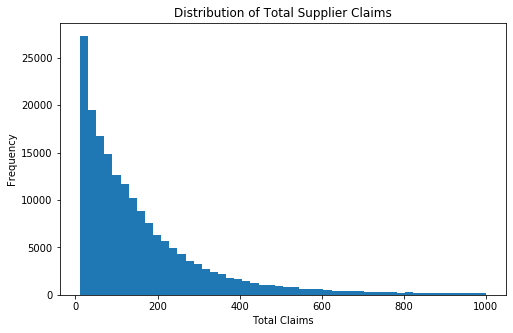

In [14]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))
# Filter to view claim under 1,000
claims = df[df['tot_suplr_clms'] <= 1000]


plt.hist(claims['tot_suplr_clms'], bins=50)
plt.title("Distribution of Total Supplier Claims")
plt.xlabel("Total Claims")
plt.ylabel("Frequency")
plt.show()

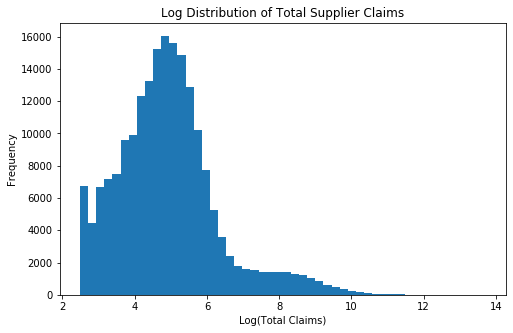

In [15]:
import numpy as np

plt.figure(figsize=(8,5))
plt.hist(np.log1p(df['tot_suplr_clms']), bins=50)
plt.title("Log Distribution of Total Supplier Claims")
plt.xlabel("Log(Total Claims)")
plt.ylabel("Frequency")
plt.show()

**Medicare Payment Distribution**

Explanation:

Total Medicare payments also show a right-skewed distribution similar to claim counts. This confirms that financial exposure is concentrated among a small number of suppliers.

When claim volume and payment volume are both heavily skewed, it indicates:

- Financial risk concentration

- Higher audit priority for top decile suppliers

- Strong justification for anomaly detection methods

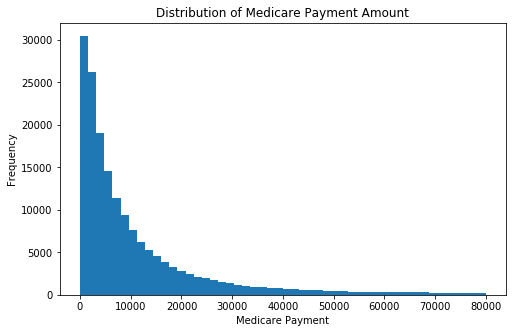

In [16]:
plt.figure(figsize=(8,5))

#Filter to view claim under 80,000
claims = df[df['suplr_mdcr_pymt_amt'] <= 80000]

plt.hist(claims['suplr_mdcr_pymt_amt'], bins=50)
plt.title("Distribution of Medicare Payment Amount")
plt.xlabel("Medicare Payment")
plt.ylabel("Frequency")
plt.show()

**Claims Trend (2021–2023)**

Explanation:

The trend between 2021 and 2023 shows how supplier billing activity changes over time.The trend shows that as the claims increase, the medicare payment amount increase.

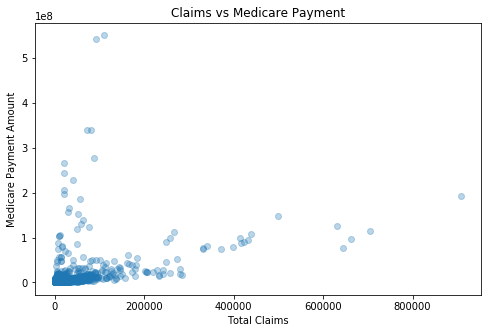

In [17]:
plt.figure(figsize=(8,5))
plt.scatter(df['tot_suplr_clms'], df['suplr_mdcr_pymt_amt'], alpha=0.3)
plt.title("Claims vs Medicare Payment")
plt.xlabel("Total Claims")
plt.ylabel("Medicare Payment Amount")
plt.show()

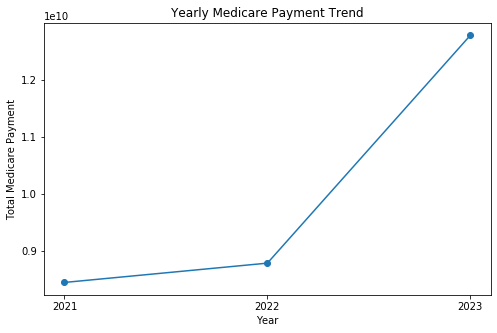

In [18]:
year_payment = df.groupby('year')['suplr_mdcr_pymt_amt'].sum()
plt.figure(figsize=(8,5))
plt.plot(year_payment.index, year_payment.values, marker='o')
plt.title("Yearly Medicare Payment Trend")
plt.xlabel("Year")
plt.ylabel("Total Medicare Payment")
plt.xticks([2021, 2022, 2023])
plt.show()

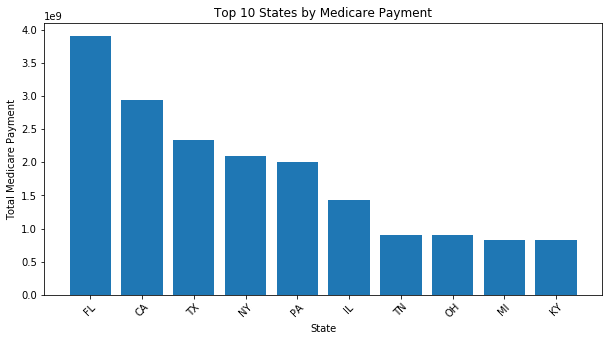

In [19]:
state_payment = df.groupby('suplr_prvdr_state_abrvtn')['suplr_mdcr_pymt_amt'].sum()
top_states = state_payment.sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.bar(top_states.index, top_states.values)
plt.title("Top 10 States by Medicare Payment")
plt.xlabel("State")
plt.ylabel("Total Medicare Payment")
plt.xticks(rotation=45)
plt.show()

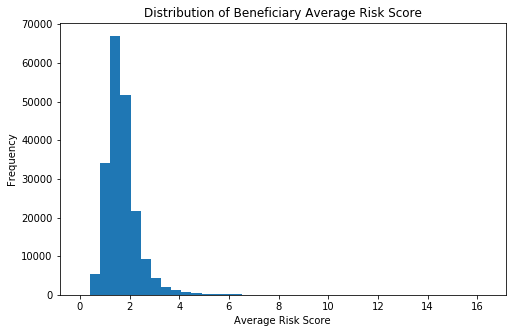

In [20]:
plt.figure(figsize=(8,5))
plt.hist(df['bene_avg_risk_scre'], bins=40)
plt.title("Distribution of Beneficiary Average Risk Score")
plt.xlabel("Average Risk Score")
plt.ylabel("Frequency")
plt.show()

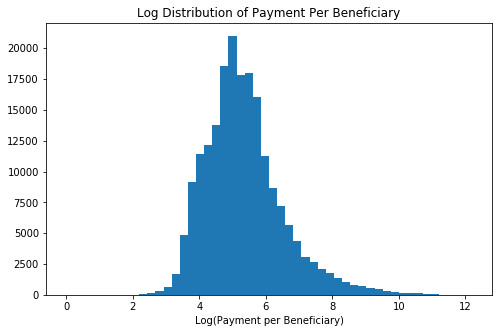

In [21]:
df['payment_per_bene'] = df['suplr_mdcr_pymt_amt'] / df['tot_suplr_benes']
plt.figure(figsize=(8,5))
plt.hist(np.log1p(df['payment_per_bene']), bins=50)
plt.title("Log Distribution of Payment Per Beneficiary")
plt.xlabel("Log(Payment per Beneficiary)")
plt.show()

In [22]:
print("DME Suppression Counts:")
print(df['dme_sprsn_ind'].value_counts())
print("\nPOS Suppression Counts:")
print(df['pos_sprsn_ind'].value_counts())

DME Suppression Counts:
*    10056
#      361
Name: dme_sprsn_ind, dtype: int64

POS Suppression Counts:
#    32811
*     6525
Name: pos_sprsn_ind, dtype: int64


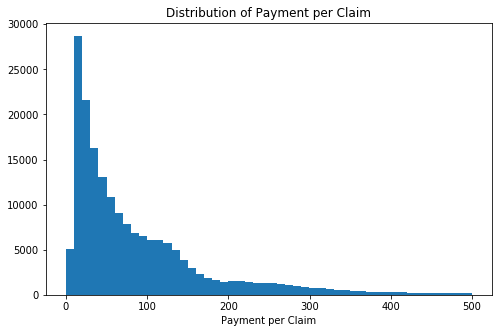

In [23]:
df['payment_per_claim'] = df['suplr_mdcr_pymt_amt'] / df['tot_suplr_clms']

#Filter to view claim under 500
claims = df[df['payment_per_claim'] <= 500]

plt.figure(figsize=(8,5))
plt.hist(claims['payment_per_claim'].dropna(), bins=50)
plt.title("Distribution of Payment per Claim")
plt.xlabel("Payment per Claim")
plt.show()

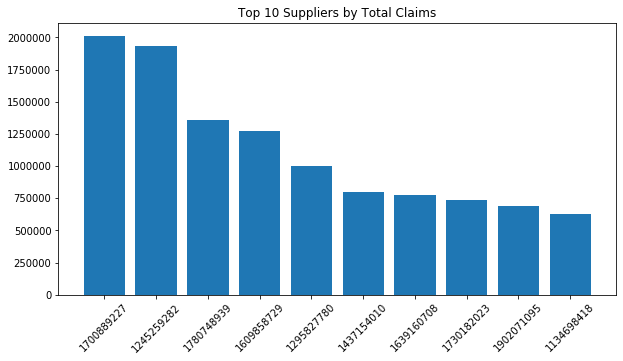

In [24]:
top_suppliers = df.groupby('suplr_npi')['tot_suplr_clms'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_suppliers.index.astype(str), top_suppliers.values)
plt.title("Top 10 Suppliers by Total Claims")
plt.xticks(rotation=45)
plt.show()

In [25]:
print(df[df['suplr_npi'] == 1700889227]['suplr_prvdr_last_name_org'].unique())

['United States Medical Supply, Llc']


In [26]:
print(df[df['suplr_prvdr_last_name_org'] == "United States Medical Supply, Llc"]['suplr_npi'].unique())
print(df[df['suplr_prvdr_last_name_org'] == "North Coast Medical Supply, Llc"]['suplr_npi'].unique())
print(df[df['suplr_prvdr_last_name_org'] == "Lincare Pharmacy Services Inc."]['suplr_npi'].unique())
print(df[df['suplr_prvdr_last_name_org'] == "Rgh Enterprises, Llc"]['suplr_npi'].unique())
print(df[df['suplr_prvdr_last_name_org'] == "Degc Enterprises (U.S.), Inc."]['suplr_npi'].unique())
print(df[df['suplr_prvdr_last_name_org'] == "Medstar Surgical & Breathing Equipment, Inc."]['suplr_npi'].unique())
print(df[df['suplr_prvdr_last_name_org'] == "180 Medical Inc"]['suplr_npi'].unique())
print(df[df['suplr_prvdr_last_name_org'] == "Ocean Home Health Supply, Llc"]['suplr_npi'].unique())
print(df[df['suplr_prvdr_last_name_org'] == "Inogen Inc"]['suplr_npi'].unique())
print(df[df['suplr_prvdr_last_name_org'] == "Super Care Inc"]['suplr_npi'].unique())

[1700889227]
[1245259282]
[1003970260 1134698418 1780748939]
[1356886030 1568878114 1609858729]
[1295827780 1710079223 1750473252]
[1134220205 1336562065 1437154010 1629409396]
[1639160708 1821344318]
[1730182023 1851497325]
[1023415163 1023425378 1114281110 1306213525 1639451909 1902071095]
[1679932198 1801376942 1902863202 1538519921]


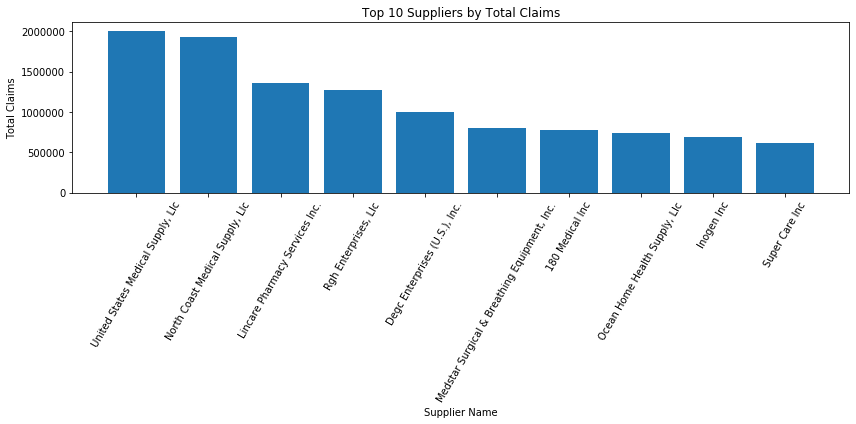

In [27]:
import matplotlib.pyplot as plt

# Group by NPI + Name (keeps suppliers unique)
top_suppliers = (
    df.groupby(['suplr_npi', 'suplr_prvdr_last_name_org'])['tot_suplr_clms']
      .sum()
      .reset_index()
      .sort_values(by='tot_suplr_clms', ascending=False)
      .head(11)
)

plt.figure(figsize=(12,6))

plt.bar(top_suppliers['suplr_prvdr_last_name_org'], 
        top_suppliers['tot_suplr_clms'])

plt.title("Top 10 Suppliers by Total Claims")
plt.xlabel("Supplier Name")
plt.ylabel("Total Claims")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

# EDA of the DMEPOS-Supplier and Service

In [28]:
d = pd.read_csv("/dsa/groups/casestudycf25/team02/silver/dmepos_suplr_serv_clean.csv")
d.head()

,year,suplr_npi,suplr_prvdr_last_name_org,suplr_prvdr_first_name,suplr_prvdr_mi,suplr_prvdr_crdntls,suplr_prvdr_ent_cd,suplr_prvdr_st1,suplr_prvdr_st2,suplr_prvdr_city,...,hcpcs_cd,hcpcs_desc,suplr_rentl_ind,tot_suplr_benes,tot_suplr_clms,tot_suplr_srvcs,avg_suplr_sbmtd_chrg,avg_suplr_mdcr_alowd_amt,avg_suplr_mdcr_pymt_amt,avg_suplr_mdcr_stdzd_amt
0,2021,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,...,L3808,"Wrist hand finger orthosis, rigid without join...",N,69.0,79,82,435.609756,325.202683,257.561707,262.395732
1,2021,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,...,L3906,"Wrist hand orthosis, without joints, may inclu...",N,30.0,30,35,448.285714,439.852857,351.134286,315.416286
2,2021,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,...,L3908,"Wrist hand orthosis, wrist extension control c...",N,84.0,99,107,108.457944,66.980000,51.914953,46.384393
3,2021,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,...,L3913,"Hand finger orthosis, without joints, may incl...",N,16.0,16,16,348.000000,247.410000,197.133125,191.759375
4,2021,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,...,L3923,"Hand finger orthosis, without joints, may incl...",N,54.0,59,66,113.030303,88.250000,66.411515,65.491667


In [29]:
# Data types
d.info()

# Summary statistics (numeric)
d.describe().T

# Missing values
missing = d.isna().sum().sort_values(ascending=False)
missing[missing > 0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1454474 entries, 0 to 1454473
Data columns (total 33 columns):
year                         1454474 non-null int64
suplr_npi                    1454474 non-null int64
suplr_prvdr_last_name_org    1454474 non-null object
suplr_prvdr_first_name       3974 non-null object
suplr_prvdr_mi               2984 non-null object
suplr_prvdr_crdntls          3145 non-null object
suplr_prvdr_ent_cd           1454474 non-null object
suplr_prvdr_st1              1454474 non-null object
suplr_prvdr_st2              217163 non-null object
suplr_prvdr_city             1454474 non-null object
suplr_prvdr_state_abrvtn     1454474 non-null object
suplr_prvdr_state_fips       1454474 non-null int64
suplr_prvdr_zip5             1454474 non-null int64
suplr_prvdr_ruca_cat         1454474 non-null object
suplr_prvdr_ruca             1454474 non-null float64
suplr_prvdr_ruca_desc        1454474 non-null object
suplr_prvdr_cntry            1454474 non-null object

suplr_prvdr_mi            1451490
suplr_prvdr_crdntls       1451329
suplr_prvdr_first_name    1450500
suplr_prvdr_st2           1237311
dtype: int64

In [30]:
# Flag suppressed beneficiary counts (<10 usually suppressed)
d["DME_Sprsn_Ind"] = np.where(d["tot_suplr_benes"].isna(), 1, 0)

d["DME_Sprsn_Ind"].value_counts()

0    1454474
Name: DME_Sprsn_Ind, dtype: int64

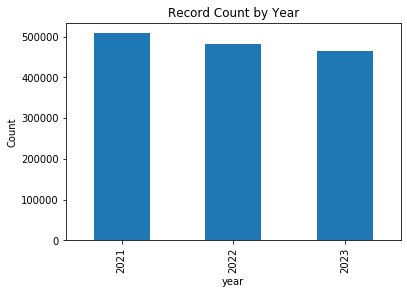

In [31]:
year_counts = d["year"].value_counts().sort_index()

plt.figure()
year_counts.plot(kind="bar")
plt.title("Record Count by Year")
plt.xlabel("year")
plt.ylabel("Count")
plt.show()

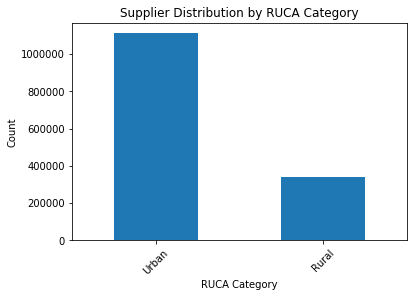

In [32]:
ruca_counts = ( d["suplr_prvdr_ruca_cat"].value_counts().reindex(["Urban", "Rural"]) )

plt.figure()
ruca_counts.plot(kind="bar")
plt.title("Supplier Distribution by RUCA Category")
plt.xlabel("RUCA Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

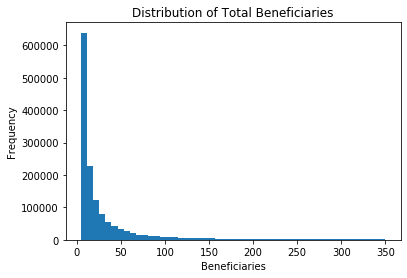

In [33]:
plt.figure()

#Filter to view claim under 1,000
claims = d[d['tot_suplr_benes'] <= 350]

claims["tot_suplr_benes"].dropna().plot(kind="hist", bins=50)
plt.title("Distribution of Total Beneficiaries")
plt.xlabel("Beneficiaries")
plt.ylabel("Frequency")
plt.show()

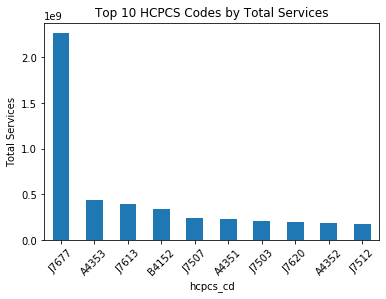

hcpcs_cd
J7677    2267874837
A4353     441402975
J7613     394695512
B4152     341472223
J7507     243559018
A4351     226591934
J7503     208119093
J7620     194775504
A4352     184850703
J7512     177131840
Name: tot_suplr_srvcs, dtype: int64

In [34]:
top_hcpcs = (
    d.groupby("hcpcs_cd")["tot_suplr_srvcs"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
top_hcpcs.plot(kind="bar")
plt.title("Top 10 HCPCS Codes by Total Services")
plt.ylabel("Total Services")
plt.xticks(rotation=45)
plt.show()

top_hcpcs

In [35]:
d['hcpcs_cd'].value_counts().head(10)

A4253    119350
A4259     96372
Q0513     69383
J7613     44464
J7620     38896
Q0511     37340
Q0512     35315
J7507     32361
J7626     21992
J7517     18343
Name: hcpcs_cd, dtype: int64

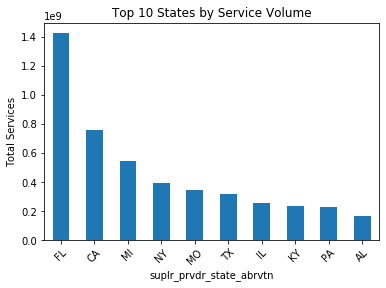

In [36]:
top_states = (
    d.groupby("suplr_prvdr_state_abrvtn")["tot_suplr_srvcs"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
top_states.plot(kind="bar")
plt.title("Top 10 States by Service Volume")
plt.ylabel("Total Services")
plt.xticks(rotation=45)
plt.show()

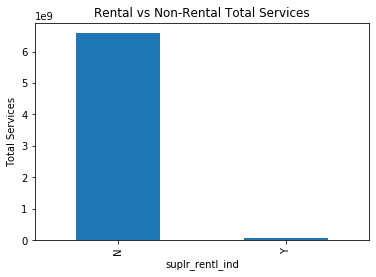

suplr_rentl_ind
N    6578234558
Y      78136614
Name: tot_suplr_srvcs, dtype: int64

In [37]:
rental_summary = (
    d.groupby("suplr_rentl_ind")["tot_suplr_srvcs"]
    .sum()
)

plt.figure()
rental_summary.plot(kind="bar")
plt.title("Rental vs Non-Rental Total Services")
plt.ylabel("Total Services")
plt.show()

rental_summary

In [38]:
# Billing markup ratio
d["Markup_Ratio"] = d["avg_suplr_sbmtd_chrg"] / d["avg_suplr_mdcr_alowd_amt"]

# Payment efficiency ratio
d["Payment_Efficiency"] = d["avg_suplr_mdcr_pymt_amt"] / d["avg_suplr_sbmtd_chrg"]

d[["Markup_Ratio", "Payment_Efficiency"]].describe()

,Markup_Ratio,Payment_Efficiency
count,1.454474e+06,1.454474e+06
mean,5.065572e+00,3.667241e-01
std,2.694614e+01,2.557175e-01
min,2.545599e-01,0.000000e+00
25%,1.257011e+00,1.063536e-01
50%,2.228626e+00,3.348731e-01
75%,6.833058e+00,6.017448e-01
max,1.257520e+04,3.079854e+00


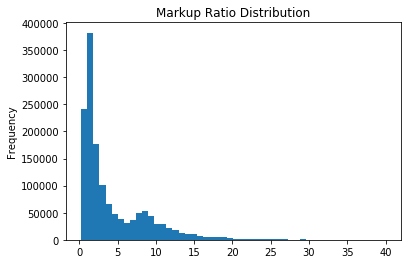

In [39]:
#Filter to view claim under 30
claims = d[d['Markup_Ratio'] <= 40]

plt.figure()
claims["Markup_Ratio"].replace([np.inf, -np.inf], np.nan).dropna().plot(kind="hist", bins=50)
plt.title("Markup Ratio Distribution")
plt.show()

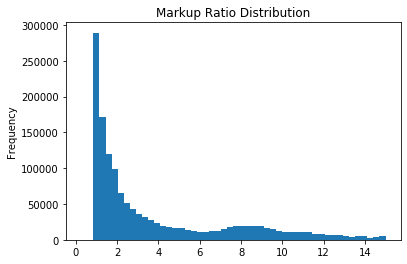

In [40]:
#Filter to view claim under 30
claims = d[d['Markup_Ratio'] <= 15]

plt.figure()
claims["Markup_Ratio"].replace([np.inf, -np.inf], np.nan).dropna().plot(kind="hist", bins=50)
plt.title("Markup Ratio Distribution")
plt.show()

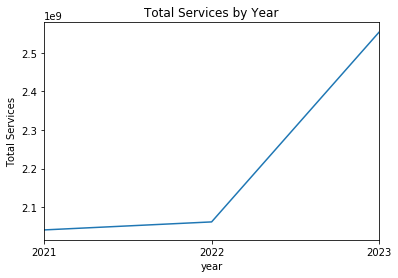

year
2021    2041052136
2022    2061811589
2023    2553507447
Name: tot_suplr_srvcs, dtype: int64

In [41]:
year_trend = (
    d.groupby("year")["tot_suplr_srvcs"]
    .sum()
)

plt.figure()
year_trend.plot(kind="line")
plt.title("Total Services by Year")
plt.ylabel("Total Services")
plt.xticks([2021, 2022, 2023])
plt.show()

year_trend

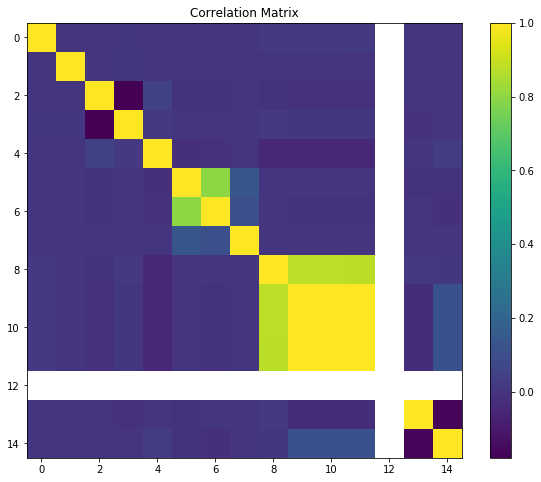

,year,suplr_npi,suplr_prvdr_state_fips,suplr_prvdr_zip5,suplr_prvdr_ruca,tot_suplr_benes,tot_suplr_clms,tot_suplr_srvcs,avg_suplr_sbmtd_chrg,avg_suplr_mdcr_alowd_amt,avg_suplr_mdcr_pymt_amt,avg_suplr_mdcr_stdzd_amt,DME_Sprsn_Ind,Markup_Ratio,Payment_Efficiency
year,1.000000,0.002771,-0.002789,0.006290,0.000790,0.002693,0.002381,0.001215,0.014130,0.018109,0.016197,0.019321,NaN,0.003499,0.000432
suplr_npi,0.002771,1.000000,0.002192,0.010685,-0.002830,0.000605,0.000251,0.000505,0.002212,0.003681,0.003697,0.003791,NaN,-0.002217,0.001735
suplr_prvdr_state_fips,-0.002789,0.002192,1.000000,-0.179751,0.052930,-0.009184,-0.008268,-0.002940,-0.006738,-0.010009,-0.010322,-0.010491,NaN,-0.002182,-0.004159
suplr_prvdr_zip5,0.006290,0.010685,-0.179751,1.000000,0.014968,0.003345,0.003558,-0.000308,0.016096,0.012621,0.012586,0.011107,NaN,-0.010791,0.004381
suplr_prvdr_ruca,0.000790,-0.002830,0.052930,0.014968,1.000000,-0.019474,-0.012022,-0.001225,-0.042452,-0.043360,-0.043759,-0.047606,NaN,-0.001107,0.026022
tot_suplr_benes,0.002693,0.000605,-0.009184,0.003345,-0.019474,1.000000,0.798759,0.137460,-0.000507,-0.002973,-0.003014,-0.002679,NaN,-0.006874,-0.007074
tot_suplr_clms,0.002381,0.000251,-0.008268,0.003558,-0.012022,0.798759,1.000000,0.105972,0.000846,-0.004868,-0.004958,-0.004701,NaN,-0.003273,-0.014186
tot_suplr_srvcs,0.001215,0.000505,-0.002940,-0.000308,-0.001225,0.137460,0.105972,1.000000,-0.001958,-0.002105,-0.002077,-0.002125,NaN,-0.000186,-0.000297
avg_suplr_sbmtd_chrg,0.014130,0.002212,-0.006738,0.016096,-0.042452,-0.000507,0.000846,-0.001958,1.000000,0.883512,0.882041,0.879256,NaN,0.015492,0.011051
avg_suplr_mdcr_alowd_amt,0.018109,0.003681,-0.010009,0.012621,-0.043360,-0.002973,-0.004868,-0.002105,0.883512,1.000000,0.999627,0.997081,NaN,-0.027067,0.116712


In [42]:
numeric_d = d.select_dtypes(include=np.number)

corr_matrix = numeric_d.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr_matrix)
plt.title("Correlation Matrix")
plt.colorbar()
plt.show()

corr_matrix

In [43]:
from scipy.stats import zscore

d["Srvcs_Z"] = zscore(d["tot_suplr_srvcs"].fillna(0))

outliers = d[np.abs(d["Srvcs_Z"]) > 3]

print("High Service Outliers:", outliers.shape)

High Service Outliers: (233, 37)
